# Module 3: Data Visualization with Matplotlib & Seaborn
## Exploring the Iris Dataset — Visual Analytics Portfolio

This notebook covers the full M3 curriculum:
- **Part 1** — Matplotlib Fundamentals (line plots, scatter plots, customisation)
- **Part 2** — Seaborn Single-Variable Plots (histograms, KDE, box plots)
- **Part 3** — Seaborn Two-Variable Plots (regression, joint plots, pair plots)

**Dataset:** [Iris Dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) — 150 samples, 4 numeric features, 3 species classes.


## 0. Setup — Install & Import Libraries

In [2]:
# Install libraries (uncomment if running fresh)
# !pip install matplotlib seaborn pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Notebook display settings ────────────────────────────────────────────
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.05)

print("✅ Libraries loaded successfully")
print(f"   matplotlib : {plt.matplotlib.__version__}")
print(f"   seaborn    : {sns.__version__}")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")


✅ Libraries loaded successfully
   matplotlib : 3.10.6
   seaborn    : 0.13.2
   pandas     : 2.2.3
   numpy      : 1.26.4


## 1. Load the Dataset

In [3]:
# Load Iris dataset from a public URL
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# Quick sanity check
print(f"Shape      : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Species    : {df['species'].unique().tolist()}")
print(f"Nulls      : {df.isnull().sum().sum()} (none expected)")
print()
df.head(8)


Shape      : 150 rows × 5 columns
Species    : ['setosa', 'versicolor', 'virginica']
Nulls      : 0 (none expected)



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa


---
## Part 1 — Introduction to Matplotlib

Matplotlib is the foundational plotting library in Python. Every Seaborn plot is
built on top of it, so understanding it first gives you full control over your visuals.


### 1A. Basic Line Plot — Sepal Length per Sample

A **line plot** is ideal for showing ordered/sequential data. Here we plot sepal length
across all 150 samples, colour-coded by species, to see how measurements shift between groups.


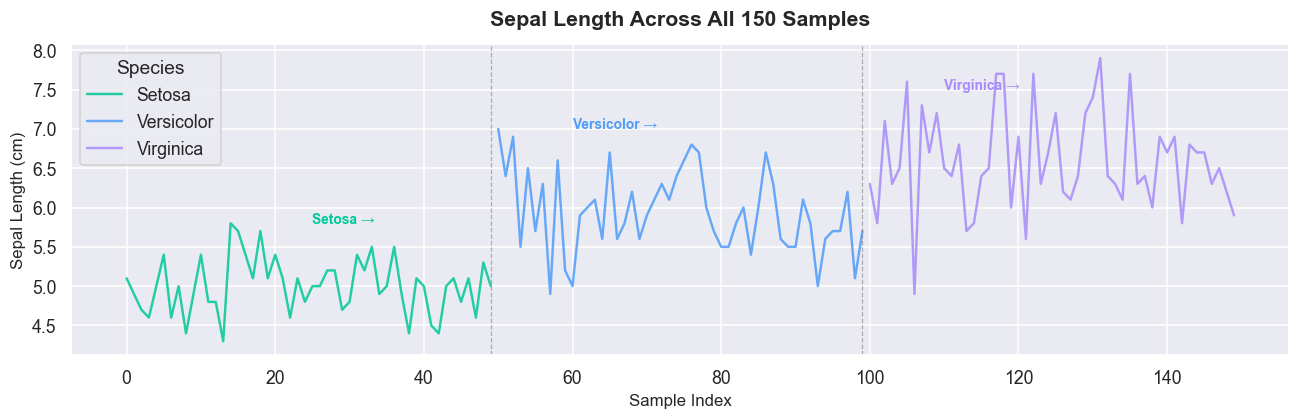

💡 Observation: Virginica consistently shows the highest sepal lengths.


In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

colors = {'setosa': '#00c896', 'versicolor': '#4f9cf9', 'virginica': '#a78bfa'}

for species, grp in df.groupby('species'):
    ax.plot(grp.index, grp['sepal_length'],
            label=species.capitalize(),
            color=colors[species],
            linewidth=1.6,
            alpha=0.85)

# ── Customisation ──────────────────────────────────────────────────────────
ax.set_title('Sepal Length Across All 150 Samples', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Sample Index', fontsize=11)
ax.set_ylabel('Sepal Length (cm)', fontsize=11)
ax.legend(title='Species', framealpha=0.85)
ax.axvline(x=49,  color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='Boundary')
ax.axvline(x=99,  color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.annotate('Setosa →', xy=(25, 5.8), fontsize=9, color='#00c896', fontweight='bold')
ax.annotate('Versicolor →', xy=(60, 7.0), fontsize=9, color='#4f9cf9', fontweight='bold')
ax.annotate('Virginica →', xy=(110, 7.5), fontsize=9, color='#a78bfa', fontweight='bold')

plt.tight_layout()
plt.show()
print("💡 Observation: Virginica consistently shows the highest sepal lengths.")


### 1B. Scatter Plot — Sepal Length vs Sepal Width

A **scatter plot** reveals the relationship between two continuous variables.
Each point represents one flower; shape encodes species for accessibility.


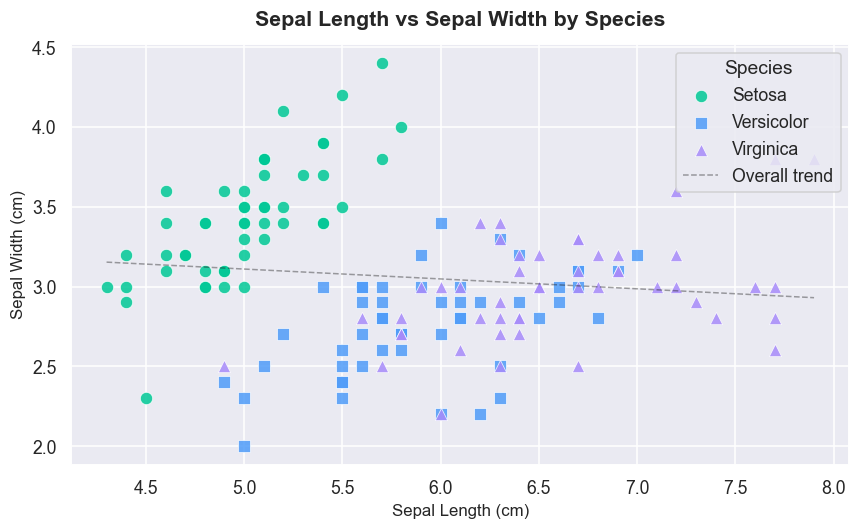

💡 Observation: Setosa is clearly separable; Versicolor and Virginica overlap more.


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

markers = {'setosa': 'o', 'versicolor': 's', 'virginica': '^'}
colors  = {'setosa': '#00c896', 'versicolor': '#4f9cf9', 'virginica': '#a78bfa'}

for species, grp in df.groupby('species'):
    ax.scatter(grp['sepal_length'], grp['sepal_width'],
               label=species.capitalize(),
               color=colors[species],
               marker=markers[species],
               s=65, edgecolors='white', linewidths=0.5, alpha=0.85)

# ── Customisation ──────────────────────────────────────────────────────────
ax.set_title('Sepal Length vs Sepal Width by Species', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Sepal Length (cm)', fontsize=11)
ax.set_ylabel('Sepal Width (cm)', fontsize=11)
ax.legend(title='Species', framealpha=0.85)

# Add a simple trend line for all data
z = np.polyfit(df['sepal_length'], df['sepal_width'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['sepal_length'].min(), df['sepal_length'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=1, alpha=0.4, label='Overall trend')
ax.legend(title='Species', framealpha=0.85)

plt.tight_layout()
plt.show()
print("💡 Observation: Setosa is clearly separable; Versicolor and Virginica overlap more.")


### 1C. Customising Plot Appearance

Matplotlib exposes fine-grained control over every visual element. This cell
demonstrates: colour palettes, grid styles, spines, tick formatting, and annotations.


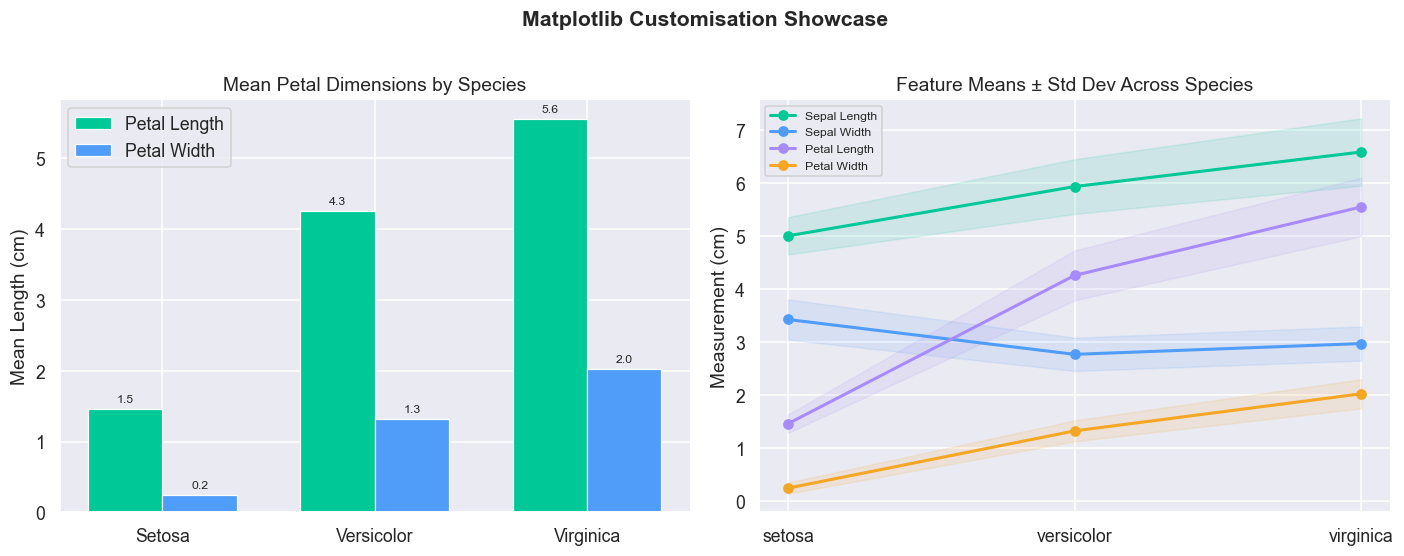

💡 Observation: Petal dimensions show the clearest species separation of all four features.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Matplotlib Customisation Showcase', fontsize=14, fontweight='bold', y=1.01)

# ── Left: Petal dimensions bar chart ───────────────────────────────────────
means = df.groupby('species')[['petal_length', 'petal_width']].mean()
x = np.arange(3)
width = 0.35

bars1 = axes[0].bar(x - width/2, means['petal_length'], width,
                    label='Petal Length', color='#00c896', edgecolor='white', linewidth=0.8)
bars2 = axes[0].bar(x + width/2, means['petal_width'],  width,
                    label='Petal Width',  color='#4f9cf9', edgecolor='white', linewidth=0.8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(['Setosa', 'Versicolor', 'Virginica'])
axes[0].set_ylabel('Mean Length (cm)')
axes[0].set_title('Mean Petal Dimensions by Species')
axes[0].legend(framealpha=0.85)
axes[0].bar_label(bars1, fmt='%.1f', padding=3, fontsize=8)
axes[0].bar_label(bars2, fmt='%.1f', padding=3, fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# ── Right: Multi-feature line with shaded std ──────────────────────────────
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
feat_colors = ['#00c896', '#4f9cf9', '#a78bfa', '#f5a623']

for feat, col in zip(features, feat_colors):
    means_f = df.groupby('species')[feat].mean()
    stds_f  = df.groupby('species')[feat].std()
    axes[1].plot(means_f.index, means_f.values, marker='o', color=col,
                 linewidth=2, label=feat.replace('_', ' ').title())
    axes[1].fill_between(means_f.index,
                          means_f.values - stds_f.values,
                          means_f.values + stds_f.values,
                          alpha=0.12, color=col)

axes[1].set_title('Feature Means ± Std Dev Across Species')
axes[1].set_ylabel('Measurement (cm)')
axes[1].legend(fontsize=8, framealpha=0.85)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print("💡 Observation: Petal dimensions show the clearest species separation of all four features.")


---
## Part 2 — Seaborn: Single-Variable Plots

Seaborn adds a statistical layer to Matplotlib. Its functions accept DataFrames
directly and automatically compute summaries, confidence intervals, and density estimates.


### 2A. Histograms & Frequency Distributions

A **histogram** divides a continuous variable into bins and shows how many
observations fall in each bin — revealing the shape of the distribution.


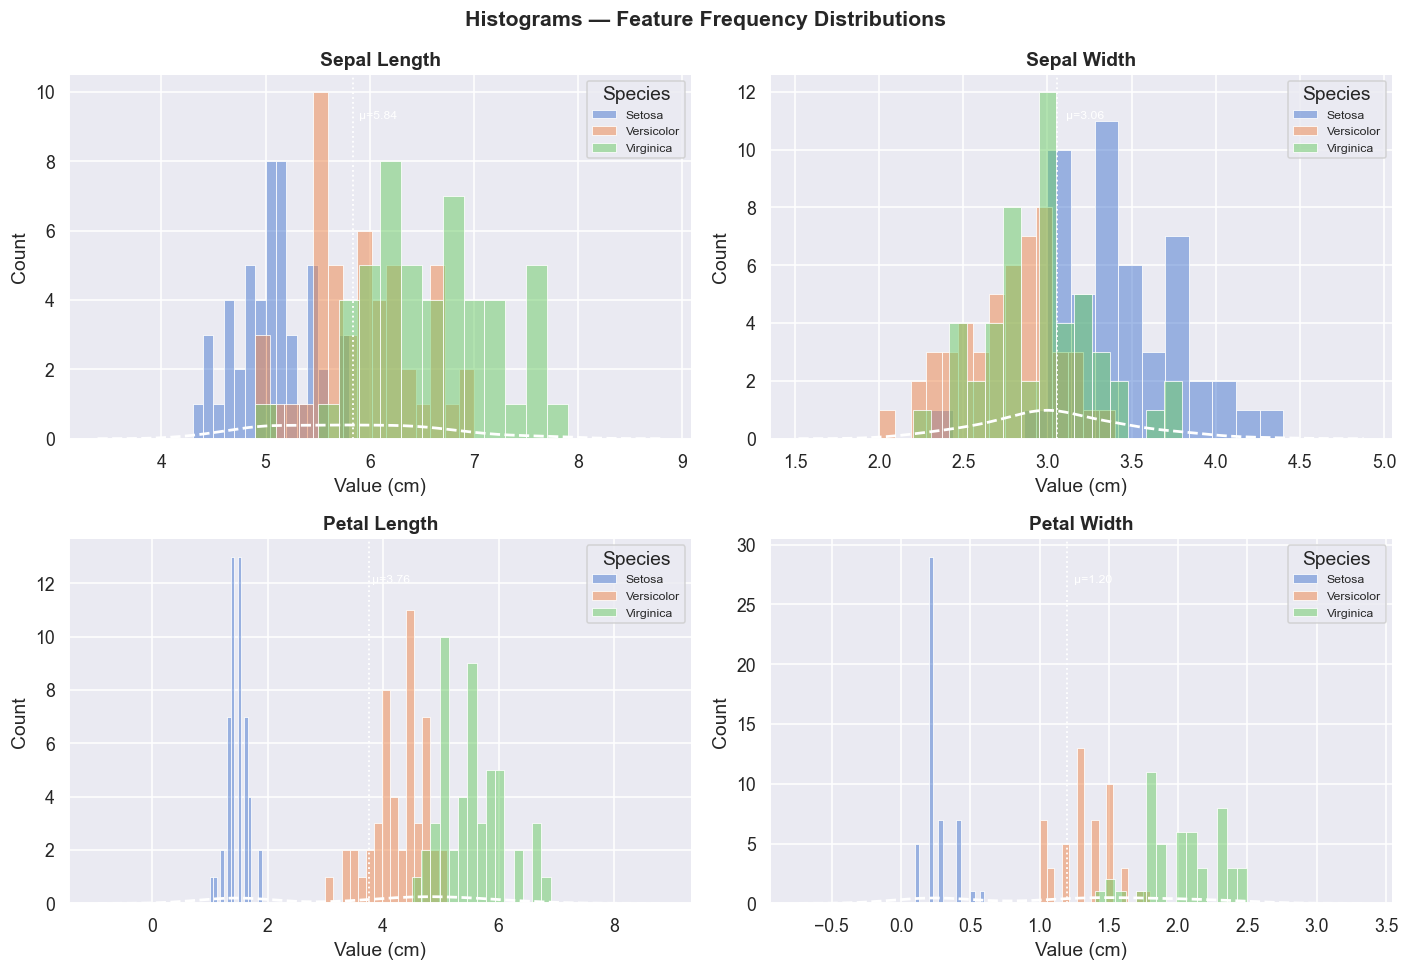

💡 Observation: Petal length and width are bimodal — Setosa forms a clearly separate cluster.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Histograms — Feature Frequency Distributions', fontsize=14, fontweight='bold')

features  = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
pal       = ['#00c896', '#4f9cf9', '#a78bfa', '#f5a623']

for ax, feat, col in zip(axes.flat, features, pal):
    # Stacked by species with KDE overlay
    for species in df['species'].unique():
        subset = df[df['species'] == species][feat]
        sns.histplot(subset, ax=ax, bins=15, kde=False,
                     label=species.capitalize(), alpha=0.5, edgecolor='white', linewidth=0.5)

    # Overall KDE on secondary y-axis feel — just overlay on same ax
    sns.kdeplot(df[feat], ax=ax, color='white', linewidth=1.8, linestyle='--')

    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Value (cm)')
    ax.set_ylabel('Count')
    ax.legend(title='Species', fontsize=8)
    ax.spines[['top','right']].set_visible(False)

    # Annotate mean
    mean_val = df[feat].mean()
    ax.axvline(mean_val, color='white', linewidth=1.2, linestyle=':')
    ax.text(mean_val + 0.05, ax.get_ylim()[1]*0.88,
            f'μ={mean_val:.2f}', fontsize=8, color='white')

plt.tight_layout()
plt.show()
print("💡 Observation: Petal length and width are bimodal — Setosa forms a clearly separate cluster.")


### 2B. Kernel Density Estimation (KDE) Plots

A **KDE plot** is a smoothed version of the histogram. Instead of discrete bins,
it draws a continuous probability density curve — useful for comparing shape across groups.


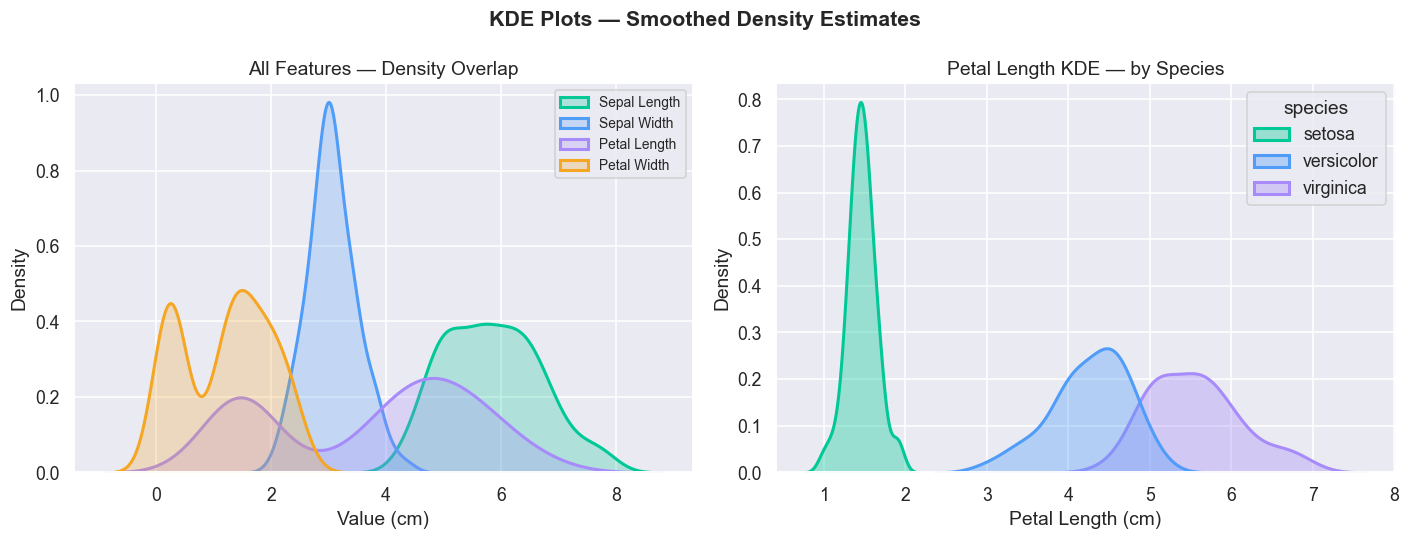

💡 Observation: Setosa (petal_length ~1.5 cm) is completely non-overlapping with the other two species.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('KDE Plots — Smoothed Density Estimates', fontsize=14, fontweight='bold')

# ── Left: All 4 features overlaid ─────────────────────────────────────────
for feat, col in zip(features, pal):
    sns.kdeplot(df[feat], ax=axes[0], fill=True, alpha=0.25,
                color=col, linewidth=2, label=feat.replace('_', ' ').title())

axes[0].set_title('All Features — Density Overlap')
axes[0].set_xlabel('Value (cm)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9, framealpha=0.85)
axes[0].spines[['top','right']].set_visible(False)

# ── Right: Petal length by species ────────────────────────────────────────
sns.kdeplot(data=df, x='petal_length', hue='species',
            ax=axes[1], fill=True, alpha=0.35, linewidth=2,
            palette=['#00c896', '#4f9cf9', '#a78bfa'])

axes[1].set_title('Petal Length KDE — by Species')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Density')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print("💡 Observation: Setosa (petal_length ~1.5 cm) is completely non-overlapping with the other two species.")


### 2C. Box Plots — Visualising Summary Statistics

A **box plot** (box-and-whisker) compactly shows the median, quartiles (IQR), and
outliers of a distribution. It's ideal for comparing spread across categories.

- **Box:** Q1 → Q3 (interquartile range)
- **Line inside box:** Median (Q2)
- **Whiskers:** 1.5 × IQR beyond Q1/Q3
- **Points beyond whiskers:** Outliers


/var/folders/gq/cw_91ncx0gb177d2wx2pv7km0000gn/T/ipykernel_53751/1640321475.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([f.replace('_', '\n') for f in features], fontsize=9)
/var/folders/gq/cw_91ncx0gb177d2wx2pv7km0000gn/T/ipykernel_53751/1640321475.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length', ax=axes[1],
/var/folders/gq/cw_91ncx0gb177d2wx2pv7km0000gn/T/ipykernel_53751/1640321475.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', ax=axes[1],


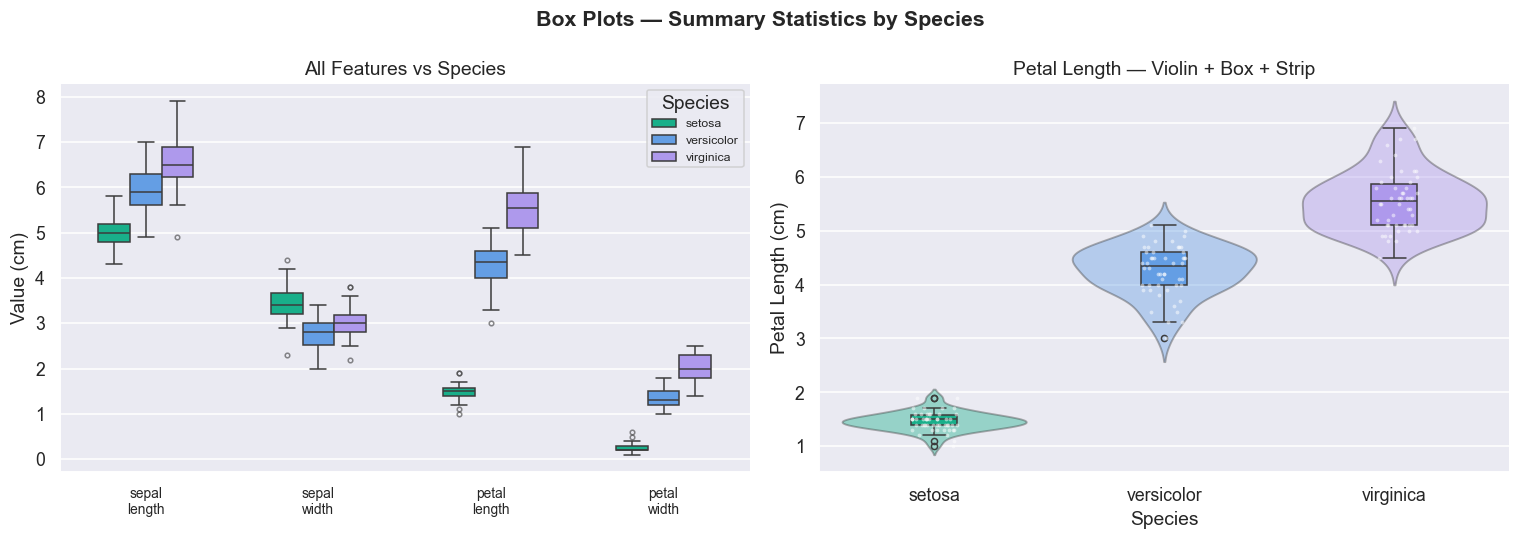

💡 Observation: The violin plot reveals Versicolor and Virginica have right-skewed petal distributions.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Box Plots — Summary Statistics by Species', fontsize=14, fontweight='bold')

palette = ['#00c896', '#4f9cf9', '#a78bfa']

# ── Left: Box plot for every feature ───────────────────────────────────────
df_melted = df.melt(id_vars='species', var_name='Feature', value_name='Value (cm)')
sns.boxplot(data=df_melted, x='Feature', y='Value (cm)', hue='species',
            ax=axes[0], palette=palette, width=0.55,
            flierprops=dict(marker='o', markersize=3, alpha=0.6))

axes[0].set_title('All Features vs Species')
axes[0].set_xlabel('')
axes[0].set_xticklabels([f.replace('_', '\n') for f in features], fontsize=9)
axes[0].legend(title='Species', fontsize=8, framealpha=0.85)
axes[0].spines[['top','right']].set_visible(False)

# ── Right: Violin + box overlay for petal length ───────────────────────────
sns.violinplot(data=df, x='species', y='petal_length', ax=axes[1],
               palette=palette, inner=None, alpha=0.4)
sns.boxplot(data=df, x='species', y='petal_length', ax=axes[1],
            palette=palette, width=0.2,
            flierprops=dict(marker='o', markersize=4))
sns.stripplot(data=df, x='species', y='petal_length', ax=axes[1],
              color='white', size=2.5, alpha=0.5, jitter=True)

axes[1].set_title('Petal Length — Violin + Box + Strip')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Petal Length (cm)')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print("💡 Observation: The violin plot reveals Versicolor and Virginica have right-skewed petal distributions.")


---
## Part 3 — Seaborn: Two-Variable Plots

Two-variable plots reveal *relationships* between features rather than the
distribution of a single variable in isolation.


### 3A. Regression Plot — `sns.regplot` & `sns.lmplot`

A **regression plot** overlays a linear fit on a scatter plot.
`lmplot` extends this by faceting per group (species here).


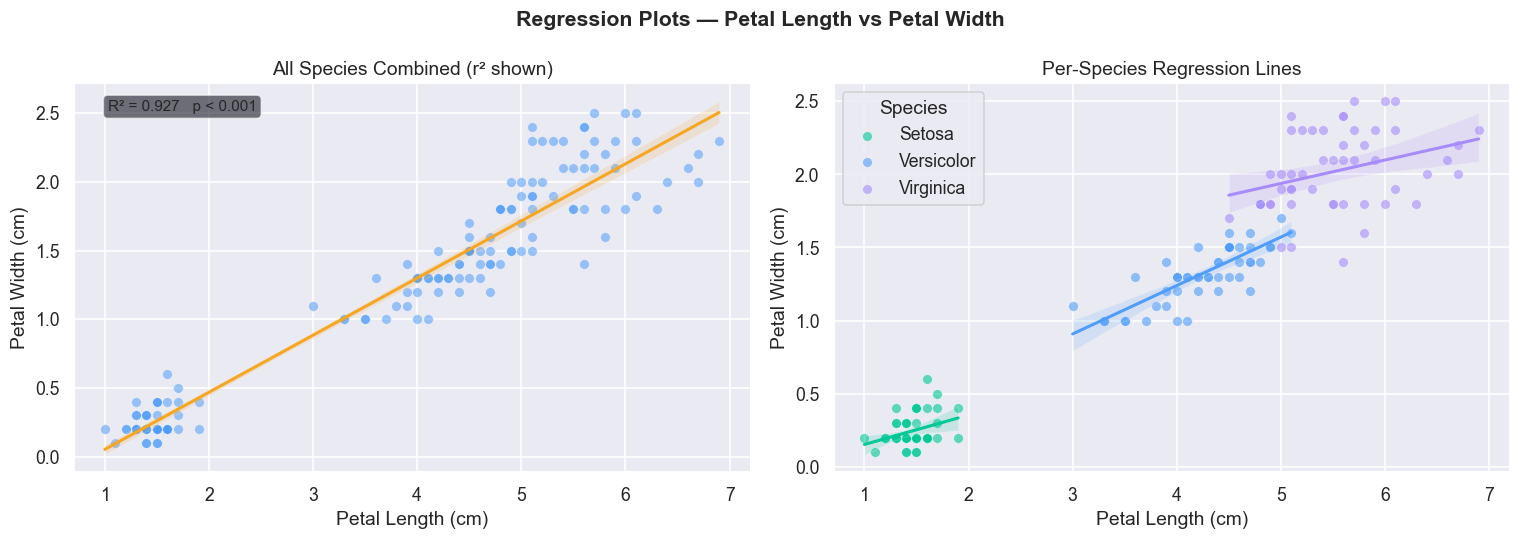

💡 Observation: R² = 0.927 — petal length explains 92.7% of the variance in petal width.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regression Plots — Petal Length vs Petal Width', fontsize=14, fontweight='bold')

palette = {'setosa': '#00c896', 'versicolor': '#4f9cf9', 'virginica': '#a78bfa'}

# ── Left: Single regression (all data) ────────────────────────────────────
sns.regplot(data=df, x='petal_length', y='petal_width', ax=axes[0],
            scatter_kws=dict(alpha=0.55, s=40, edgecolor='white', linewidths=0.4),
            line_kws=dict(color='#f5a623', linewidth=2),
            color='#4f9cf9')

axes[0].set_title('All Species Combined (r² shown)')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].spines[['top','right']].set_visible(False)

# Add R² annotation
from scipy import stats as sp_stats
slope, intercept, r, p, se = sp_stats.linregress(df['petal_length'], df['petal_width'])
axes[0].text(0.05, 0.93, f'R² = {r**2:.3f}   p < 0.001',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1a26', alpha=0.6))

# ── Right: Per-species regression ─────────────────────────────────────────
for species, grp in df.groupby('species'):
    col = palette[species]
    sns.regplot(data=grp, x='petal_length', y='petal_width', ax=axes[1],
                scatter_kws=dict(alpha=0.6, s=40, color=col, edgecolor='white', linewidths=0.4),
                line_kws=dict(color=col, linewidth=2),
                label=species.capitalize(), color=col)

axes[1].set_title('Per-Species Regression Lines')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend(title='Species', framealpha=0.85)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()
print(f"💡 Observation: R² = {r**2:.3f} — petal length explains {r**2*100:.1f}% of the variance in petal width.")


### 3B. Joint Plot — Bivariate Analysis

A **joint plot** combines a scatter/density plot in the centre with marginal
univariate distributions on each axis — giving a complete bivariate picture.


/var/folders/gq/cw_91ncx0gb177d2wx2pv7km0000gn/T/ipykernel_53751/1066622080.py:20: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(grp['sepal_width'],  ax=g.ax_marg_y,
/var/folders/gq/cw_91ncx0gb177d2wx2pv7km0000gn/T/ipykernel_53751/1066622080.py:20: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(grp['sepal_width'],  ax=g.ax_marg_y,
/var/folders/gq/cw_91ncx0gb177d2wx2pv7km0000gn/T/ipykernel_53751/1066622080.py:20: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(grp['sepal_width'],  ax=g.ax_marg_y,


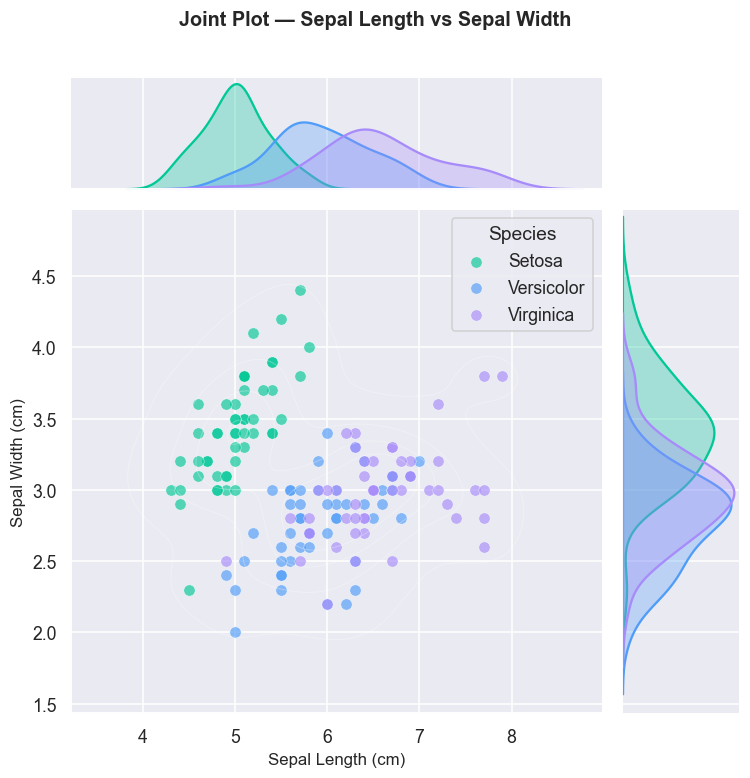

💡 Observation: The marginal KDEs show Setosa has narrower sepal length but wider sepal width than the other species.


In [11]:
# Joint plot — sepal length vs sepal width, coloured by species
g = sns.JointGrid(data=df, x='sepal_length', y='sepal_width', height=7, ratio=4)

palette = {'setosa': '#00c896', 'versicolor': '#4f9cf9', 'virginica': '#a78bfa'}

# Centre: scatter
for species, grp in df.groupby('species'):
    g.ax_joint.scatter(grp['sepal_length'], grp['sepal_width'],
                       color=palette[species], alpha=0.65, s=55,
                       edgecolor='white', linewidths=0.4, label=species.capitalize())

# Centre: contour (density)
sns.kdeplot(data=df, x='sepal_length', y='sepal_width',
            ax=g.ax_joint, levels=5, color='white', linewidths=0.6, alpha=0.3)

# Marginals: KDE per species
for species, grp in df.groupby('species'):
    sns.kdeplot(grp['sepal_length'], ax=g.ax_marg_x,
                color=palette[species], fill=True, alpha=0.3, linewidth=1.5)
    sns.kdeplot(grp['sepal_width'],  ax=g.ax_marg_y,
                color=palette[species], fill=True, alpha=0.3, linewidth=1.5, vertical=True)

g.ax_joint.legend(title='Species', framealpha=0.85)
g.ax_joint.set_xlabel('Sepal Length (cm)', fontsize=11)
g.ax_joint.set_ylabel('Sepal Width (cm)', fontsize=11)
g.fig.suptitle('Joint Plot — Sepal Length vs Sepal Width', y=1.01,
               fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print("💡 Observation: The marginal KDEs show Setosa has narrower sepal length but wider sepal width than the other species.")


### 3C. Pair Plot — Exploring All Feature Relationships

A **pair plot** (scatter plot matrix) shows every pairwise combination of numeric
features in one grid. The diagonal shows each feature's own distribution.
It's the fastest way to survey a dataset for structure and correlations.


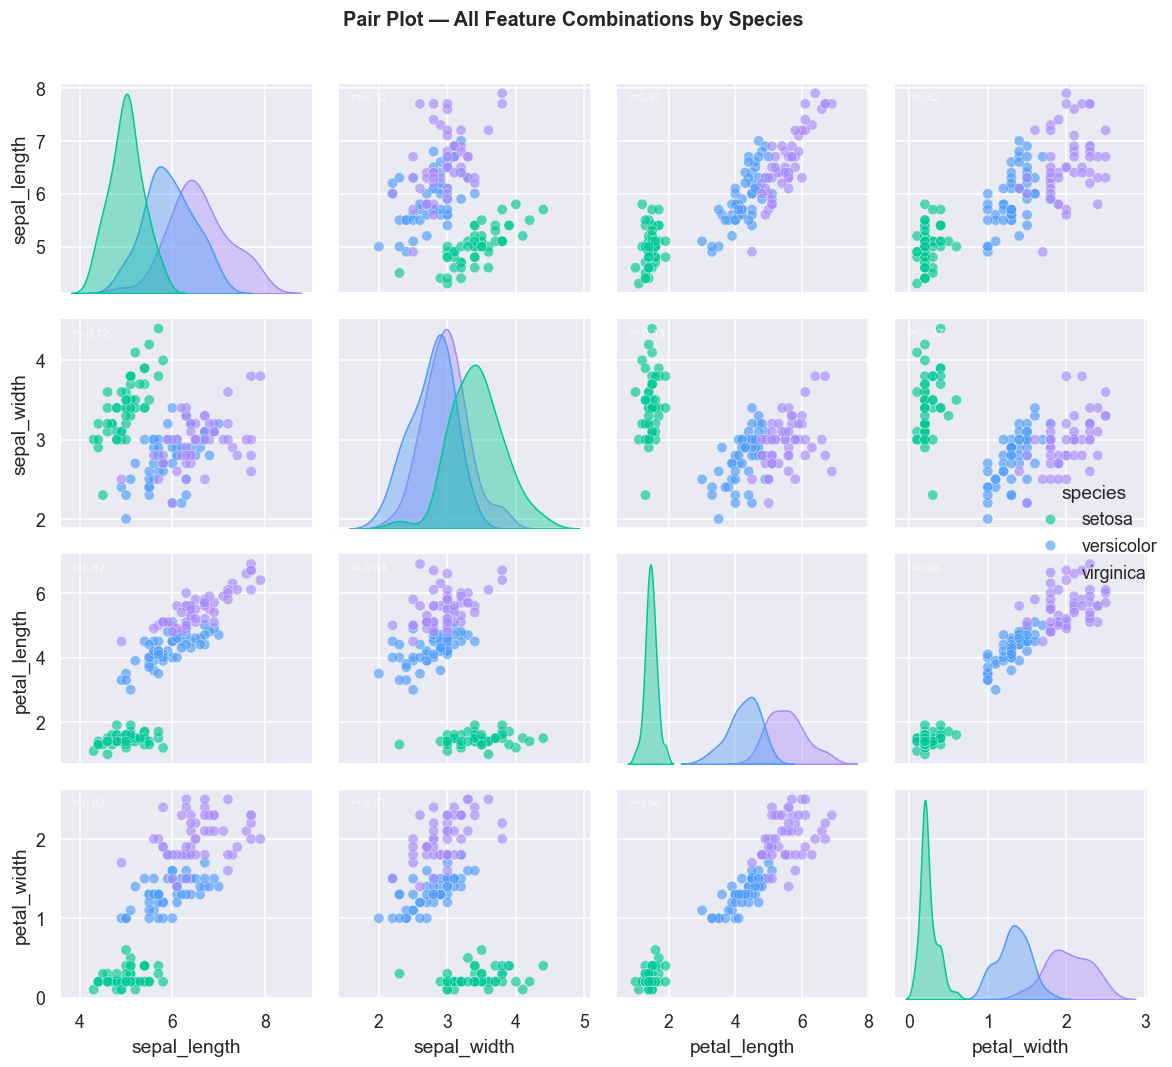

💡 Observation: petal_length vs petal_width (r=0.96) is the strongest linear relationship in the dataset.


In [12]:
g = sns.pairplot(
    df,
    hue='species',
    palette={'setosa': '#00c896', 'versicolor': '#4f9cf9', 'virginica': '#a78bfa'},
    diag_kind='kde',          # KDE on the diagonal
    plot_kws=dict(alpha=0.65, s=45, edgecolor='white', linewidths=0.3),
    diag_kws=dict(fill=True, alpha=0.4),
    corner=False,
    height=2.4
)

g.fig.suptitle('Pair Plot — All Feature Combinations by Species',
               y=1.01, fontsize=13, fontweight='bold')

# Add a correlation annotation to each off-diagonal axis
for i, feat_y in enumerate(features):
    for j, feat_x in enumerate(features):
        if i != j:
            ax = g.axes[i][j]
            r_val, _ = sp_stats.pearsonr(df[feat_x], df[feat_y])
            ax.text(0.05, 0.92, f'r={r_val:.2f}',
                    transform=ax.transAxes, fontsize=7.5,
                    color='white', alpha=0.75)

plt.tight_layout()
plt.show()
print("💡 Observation: petal_length vs petal_width (r=0.96) is the strongest linear relationship in the dataset.")


---
## Summary

| Plot Type | Library | Best Used For |
|-----------|---------|---------------|
| **Line plot** | Matplotlib | Sequential / ordered data |
| **Scatter plot** | Matplotlib | Two continuous variables |
| **Bar chart** | Matplotlib | Comparing discrete categories |
| **Histogram** | Seaborn | Distribution shape & frequency |
| **KDE plot** | Seaborn | Smoothed density, comparing groups |
| **Box plot** | Seaborn | Median, spread, and outliers |
| **Violin plot** | Seaborn | Distribution shape + summary stats |
| **Regression plot** | Seaborn | Linear relationship + confidence band |
| **Joint plot** | Seaborn | Bivariate + marginal distributions |
| **Pair plot** | Seaborn | All pairwise relationships at once |

### Key Findings from the Iris Dataset
1. **Setosa is linearly separable** from the other two species using petal dimensions alone.
2. **Petal length and petal width are highly correlated** (r = 0.96) — the strongest relationship in the dataset.
3. **Sepal width** shows the weakest species discrimination; sepal length is moderately useful.
4. **Versicolor and Virginica overlap** in sepal space but are distinguishable in petal space.
